In [1]:
import numpy as np
import pandas as pd

# Cargar el dataset USD/MXN de Investing.com
df = pd.read_csv('USD_MXN.csv')
print(df.shape)
print(df.dtypes)
df.head()

(1608, 7)
Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object


,Date,Price,Open,High,Low,Vol.,Change %
0,03/13/2026,17.9535,17.8610,17.9780,17.7470,NaN,0.52%
1,03/12/2026,17.8615,17.6747,17.8995,17.6373,NaN,1.04%
2,03/11/2026,17.6785,17.6050,17.7135,17.5255,NaN,0.45%
3,03/10/2026,17.5988,17.6125,17.7025,17.4480,NaN,-0.08%
4,03/09/2026,17.6125,17.8175,18.0256,17.5916,NaN,-1.06%


In [2]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date').reset_index(drop=True)

# Eliminar columna Vol
df = df.drop(columns=['Vol.'])

# Limpiar Change % 
df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

print(df.shape)
print(df.dtypes)
df.head()

(1608, 6)
Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Change %           float64
dtype: object


,Date,Price,Open,High,Low,Change %
0,2020-01-15,18.7831,18.7830,18.8285,18.7635,0.04
1,2020-01-16,18.7722,18.7920,18.8157,18.7690,-0.06
2,2020-01-17,18.6549,18.7797,18.7904,18.6529,-0.62
3,2020-01-20,18.6586,18.6615,18.6960,18.6444,0.02
4,2020-01-21,18.7625,18.6639,18.8045,18.6617,0.56


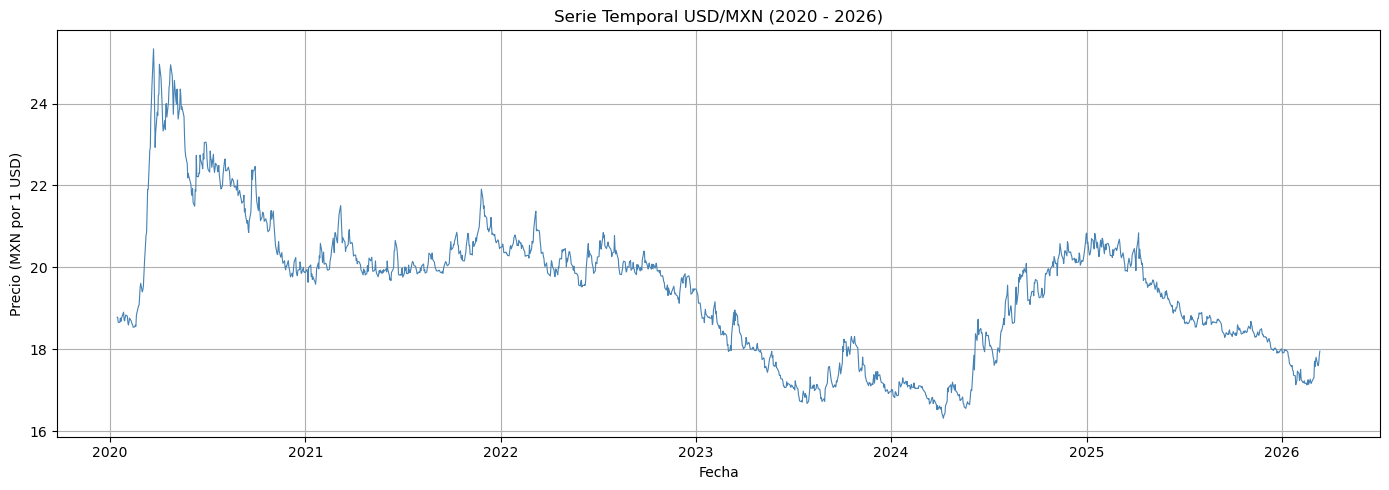

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=0.8)
plt.title('Serie Temporal USD/MXN (2020 - 2026)')
plt.xlabel('Fecha')
plt.ylabel('Precio (MXN por 1 USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import MinMaxScaler

# Usamos solo el precio de cierre(array) 2D 
prices = df['Price'].values.reshape(-1, 1)

# Normalizar entre 0 y 1
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices).flatten()

n_steps = 50  

def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

X, y = create_sequences(prices_scaled, n_steps)

# Split 70% train / 15% val / 15% test
n = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X[:n_train],                    y[:n_train]
X_val,   y_val   = X[n_train:n_train + n_val],     y[n_train:n_train + n_val]
X_test,  y_test  = X[n_train + n_val:],            y[n_train + n_val:]

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (1090, 50)  y_train: (1090, 1)
X_val:   (233, 50)
X_test:  (235, 50)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDatasetRNN(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X = X[..., np.newaxis]
        self.y = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset_rnn = {
    'train': TimeSeriesDatasetRNN(X_train, y_train),
    'eval':  TimeSeriesDatasetRNN(X_val, y_val),
    'test':  TimeSeriesDatasetRNN(X_test, train=False)
}

dataloader_rnn = {
    'train': DataLoader(dataset_rnn['train'], shuffle=True,  batch_size=64),
    'eval':  DataLoader(dataset_rnn['eval'],  shuffle=False, batch_size=64),
    'test':  DataLoader(dataset_rnn['test'],  shuffle=False, batch_size=64)
}

# Verificar shapes
sample_X, sample_y = dataset_rnn['train'][0]
print(f'Shape X: {sample_X.shape}')  # esperado: torch.Size([50, 1])
print(f'Shape y: {sample_y.shape}')  # esperado: torch.Size([1])

Shape X: torch.Size([50, 1])
Shape y: torch.Size([1])


In [20]:
class DeepRNN(torch.nn.Module):
    def __init__(self, n_in=1, n_out=1):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=1, hidden_size=64, num_layers=2, batch_first=True)
        self.fc = torch.nn.Linear(64, n_out)

    def forward(self, x):
        x, h = self.rnn(x)
        x = self.fc(x[:, -1])
        return x

rnn = DeepRNN()
print(rnn)

DeepRNN(
  (rnn): RNN(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [29]:
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')

def fit(model, dataloader, epochs=200):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs+1))
    for epoch in bar:
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                eval_loss.append(loss.item())
        bar.set_description(f"loss {np.mean(train_loss):.5f} val_loss {np.mean(eval_loss):.5f}")

def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X = batch
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds

Usando: cuda


In [22]:
fit(rnn, dataloader_rnn)

loss 0.00033 val_loss 0.00040: 100%|██████████| 100/100 [00:08<00:00, 11.85it/s]


In [23]:
from sklearn.metrics import mean_squared_error


y_pred_rnn = predict(rnn, dataloader_rnn['test'])

# Desnormalizar
y_pred_rnn_real = scaler.inverse_transform(y_pred_rnn.cpu().numpy())
y_test_real = scaler.inverse_transform(y_test)  # ← agregar esta línea

mse_rnn  = mean_squared_error(y_test_real, y_pred_rnn_real)
print(f'MSE:  {mse_rnn:.5f}')
print(f'RMSE: {mse_rnn**0.5:.4f} MXN')

MSE:  0.00915
RMSE: 0.0957 MXN


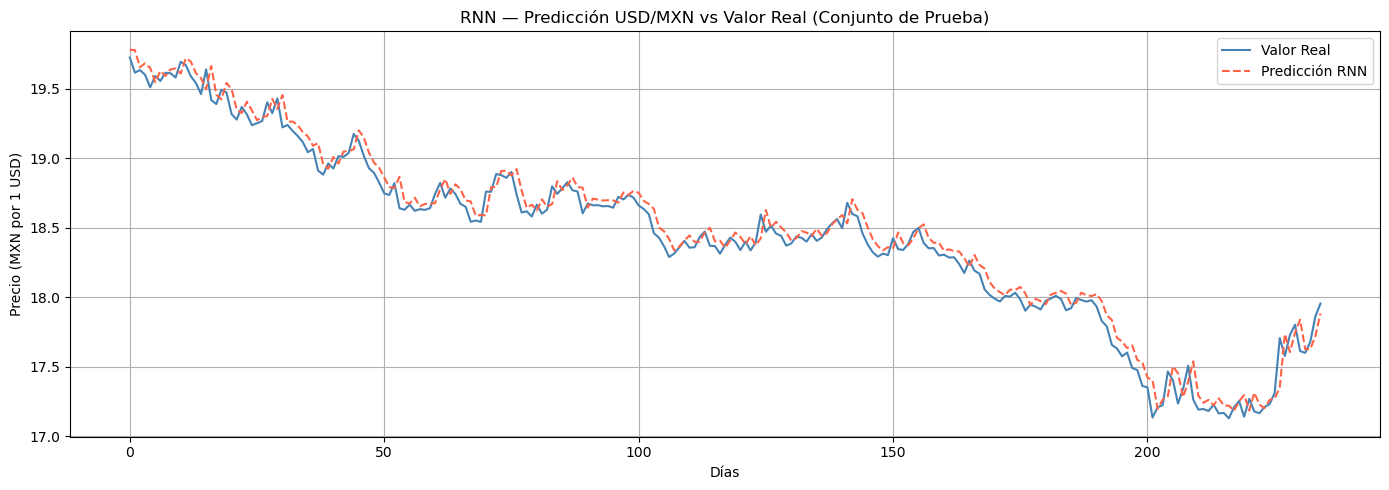

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real, label='Valor Real', color='steelblue', linewidth=1.5)
plt.plot(y_pred_rnn_real, label='Predicción RNN', color='tomato', linewidth=1.5, linestyle='--')
plt.title('RNN — Predicción USD/MXN vs Valor Real (Conjunto de Prueba)')
plt.xlabel('Días')
plt.ylabel('Precio (MXN por 1 USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

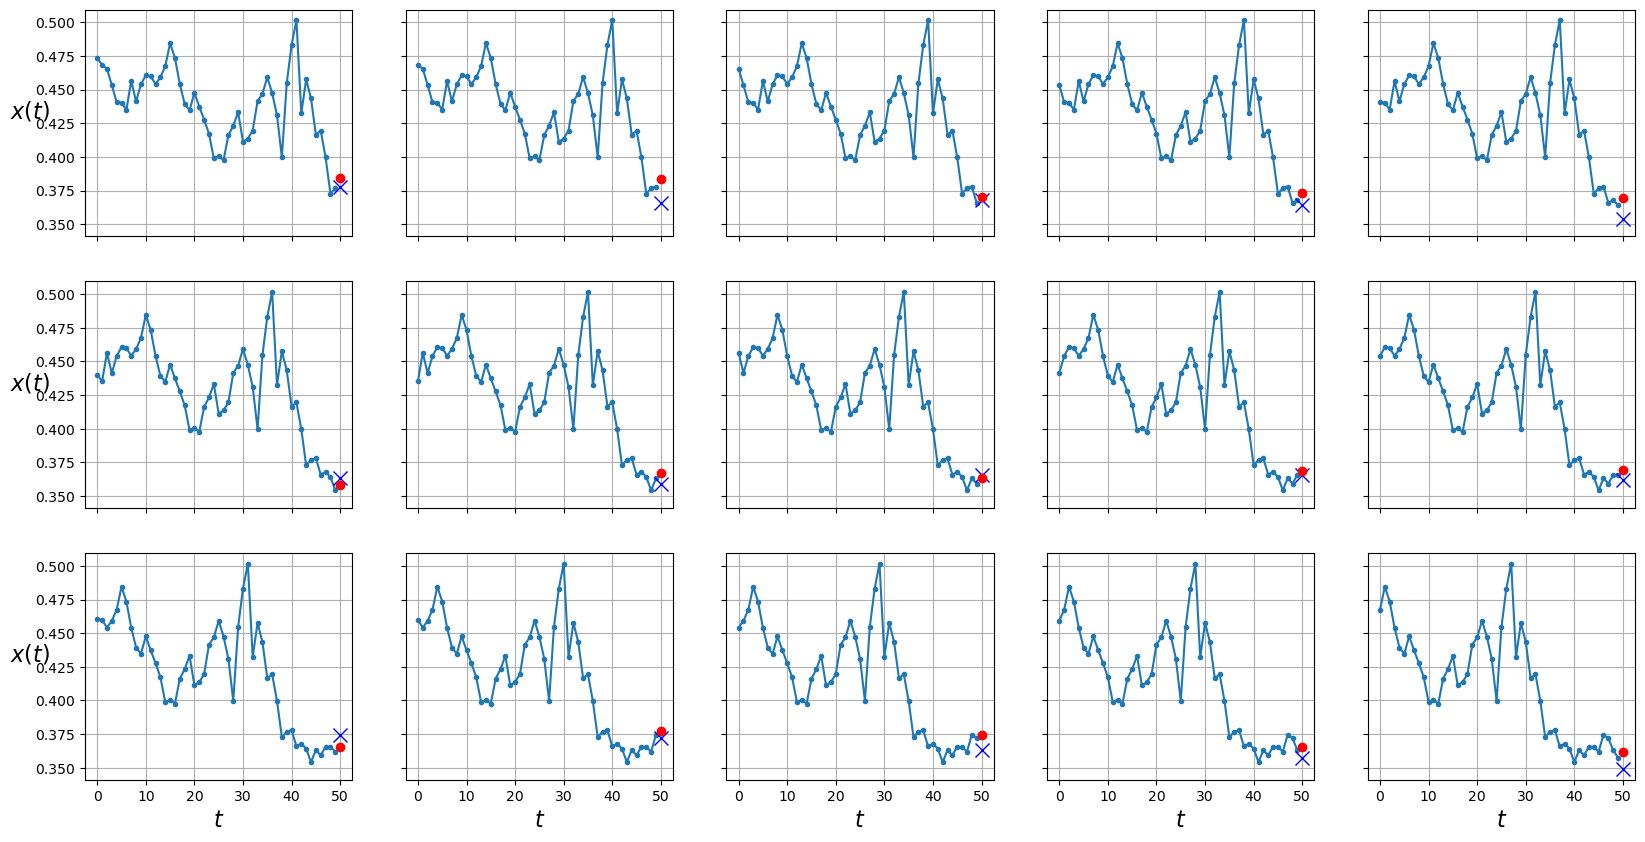

0.00011236478894716129


In [25]:
def plot_series(series, y=None, y_pred_rnn=None, x_label="$t$", y_label="$x(t)$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            plt.plot(series[ix], ".-")
            if y is not None:
                plt.plot(len(series[ix]), y[ix], "bx", markersize=10)
            if y_pred_rnn is not None:
                plt.plot(len(series[ix]), y_pred_rnn[ix], "ro")
            plt.grid(True)
            if x_label and row == r - 1:
                plt.xlabel(x_label, fontsize=16)
            if y_label and col == 0:
                plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.show()

y_pred_rnn = predict(rnn, dataloader_rnn['test'])
plot_series(X_test, y_test, y_pred_rnn.cpu().numpy())
print(mean_squared_error(y_test, y_pred_rnn.cpu().numpy()))

In [30]:
n_steps = 100
prices_scaled_2d = prices_scaled  


def create_sequences_multi(data, n_steps, n_out=10):
    X, y = [], []
    for i in range(len(data) - n_steps - n_out + 1):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps:i + n_steps + n_out])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_multi, y_multi = create_sequences_multi(prices_scaled, n_steps, n_out=10)

n = len(X_multi)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train_m = X_multi[:n_train]
y_train_m = y_multi[:n_train]
X_val_m   = X_multi[n_train:n_train + n_val]
y_val_m   = y_multi[n_train:n_train + n_val]
X_test_m  = X_multi[n_train + n_val:]
y_test_m  = y_multi[n_train + n_val:]

print(f'X_train: {X_train_m.shape}  y_train: {y_train_m.shape}')
print(f'X_val:   {X_val_m.shape}    y_val:   {y_val_m.shape}')
print(f'X_test:  {X_test_m.shape}   y_test:  {y_test_m.shape}')

X_train: (1049, 100)  y_train: (1049, 10)
X_val:   (224, 100)    y_val:   (224, 10)
X_test:  (226, 100)   y_test:  (226, 10)


In [31]:
dataset_multi = {
    'train': TimeSeriesDatasetRNN(X_train_m, y_train_m),
    'eval':  TimeSeriesDatasetRNN(X_val_m,   y_val_m),
    'test':  TimeSeriesDatasetRNN(X_test_m,  train=False)
}

dataloader_multi = {
    'train': DataLoader(dataset_multi['train'], shuffle=True,  batch_size=64),
    'eval':  DataLoader(dataset_multi['eval'],  shuffle=False, batch_size=64),
    'test':  DataLoader(dataset_multi['test'],  shuffle=False, batch_size=64)
}

# Verificar shape
sample_X, sample_y = dataset_multi['train'][0]
print(f'Shape X: {sample_X.shape}')  # esperado: torch.Size([50, 1])
print(f'Shape y: {sample_y.shape}')  # esperado: torch.Size([10])

Shape X: torch.Size([100, 1])
Shape y: torch.Size([10])


In [32]:
class DeepRNN_Multi(torch.nn.Module):
    def __init__(self, n_out=10):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=1, hidden_size=64,
                                num_layers=3, batch_first=True)
        self.fc = torch.nn.Linear(64, n_out)  # ← ahora predice 10

    def forward(self, x):
        x, h = self.rnn(x)
        x = self.fc(x[:, -1])  # solo el último estado → (batch, 10)
        return x

rnn_multi = DeepRNN_Multi()
print(rnn_multi)

DeepRNN_Multi(
  (rnn): RNN(1, 64, num_layers=3, batch_first=True)
  (fc): Linear(in_features=64, out_features=10, bias=True)
)


In [33]:
fit(rnn_multi, dataloader_multi)

loss 0.00155 val_loss 0.00182: 100%|██████████| 200/200 [00:16<00:00, 12.49it/s]


loss 0.00151 val_loss 0.00202: 100%|██████████| 100/100 [00:07<00:00, 12.58it/s]

In [34]:
from sklearn.metrics import mean_squared_error

y_pred_multi = predict(rnn_multi, dataloader_multi['test'])

# Desnormalizar
y_pred_multi_real = scaler.inverse_transform(y_pred_multi.cpu().numpy())
y_test_multi_real = scaler.inverse_transform(y_test_m)

# MSE y RMSE del último día predicho (día 10)
mse_multi = mean_squared_error(y_test_multi_real[:, -1], y_pred_multi_real[:, -1])
print(f'MSE  (día 10): {mse_multi:.5f}')
print(f'RMSE (día 10): {mse_multi**0.5:.4f} MXN')

# MSE promedio de los 10 días
mse_promedio = mean_squared_error(y_test_multi_real, y_pred_multi_real)
print(f'MSE  (promedio 10 días): {mse_promedio:.5f}')
print(f'RMSE (promedio 10 días): {mse_promedio**0.5:.4f} MXN')

MSE  (día 10): 0.04554
RMSE (día 10): 0.2134 MXN
MSE  (promedio 10 días): 0.03752
RMSE (promedio 10 días): 0.1937 MXN


C:\Users\luisc\AppData\Local\Temp\ipykernel_31676\4065508922.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


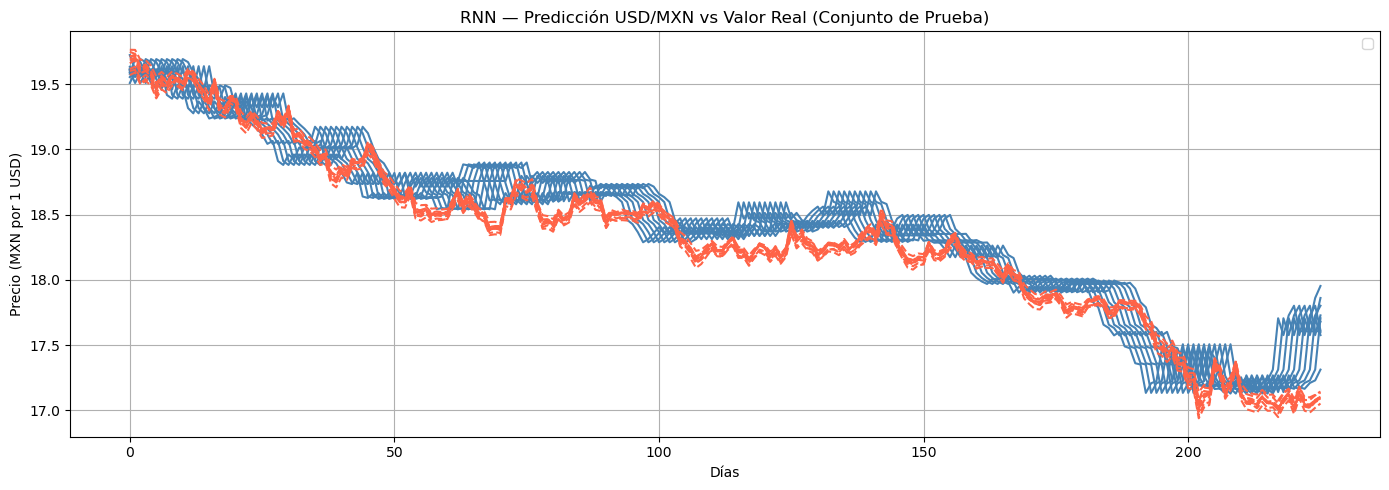

In [35]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_multi_real, color='steelblue', linewidth=1.5)
plt.plot(y_pred_multi_real, color='tomato', linewidth=1.5, linestyle='--')
plt.title('RNN — Predicción USD/MXN vs Valor Real (Conjunto de Prueba)')
plt.xlabel('Días')
plt.ylabel('Precio (MXN por 1 USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

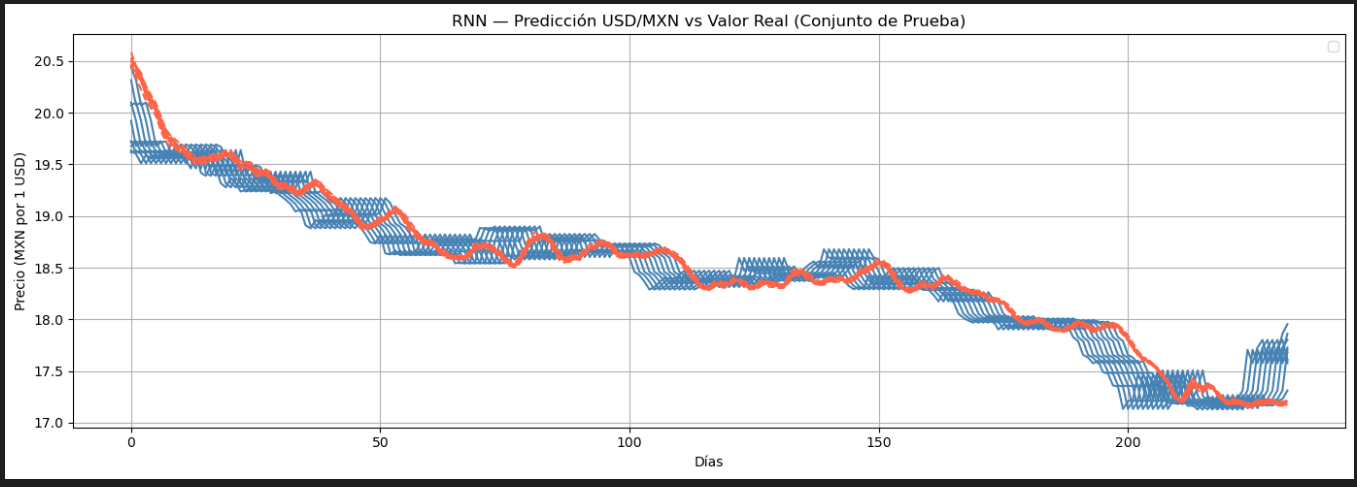

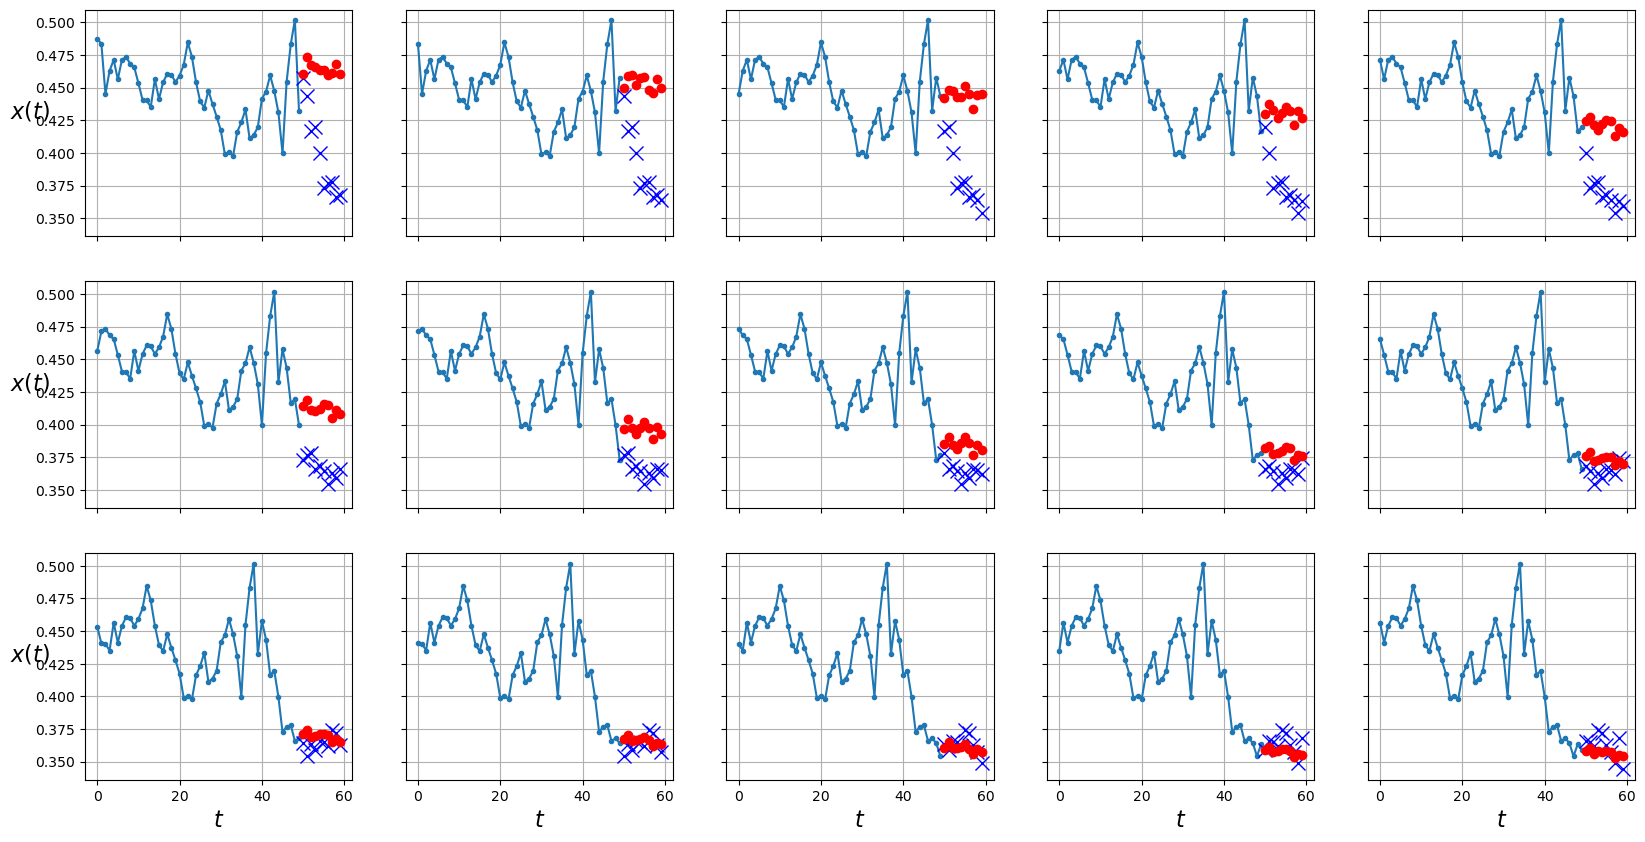

0.000433553010225296


In [19]:
def plot_series_multi(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            plt.plot(series[ix], ".-")
            if y is not None:
                # graficar los 10 valores reales en posiciones 50,51,...59
                plt.plot(range(len(series[ix]), len(series[ix]) + len(y[ix])), y[ix], "bx", markersize=10)
            if y_pred is not None:
                # graficar los 10 valores predichos en las mismas posiciones
                plt.plot(range(len(series[ix]), len(series[ix]) + len(y_pred[ix])), y_pred[ix], "ro")
            plt.grid(True)
            if x_label and row == r - 1:
                plt.xlabel(x_label, fontsize=16)
            if y_label and col == 0:
                plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.show()

plot_series_multi(X_test_m, y_test_m, y_pred_multi.cpu().numpy())
print(mean_squared_error(y_test_m, y_pred_multi.cpu().numpy()))

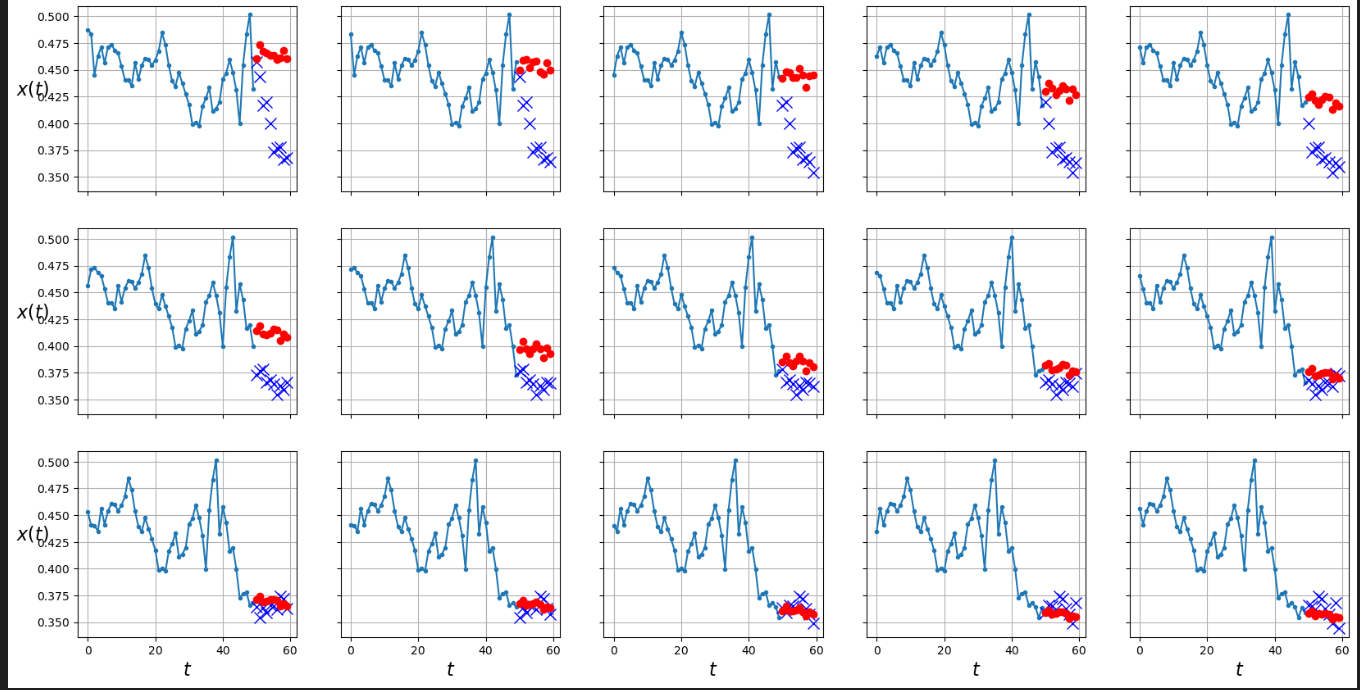

In [20]:
# Paso 1 — DeepRNN con Dropout
class DeepRNN_Multi(torch.nn.Module):
    def __init__(self, n_out=10, dropout=0.3):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=1, hidden_size=20,
                                num_layers=2, batch_first=True,
                                dropout=dropout)
        self.fc = torch.nn.Linear(20, n_out)

    def forward(self, x):
        x, h = self.rnn(x)
        x = self.fc(x[:, -1])
        return x

rnn_multi = DeepRNN_Multi(dropout=0.3)
fit(rnn_multi, dataloader_multi)

loss 0.00183 val_loss 0.00203: 100%|██████████| 100/100 [00:08<00:00, 12.34it/s]


loss 0.00183 val_loss 0.00203: 100%|██████████| 100/100 [00:08<00:00, 12.34it/s]

In [ ]:
def predict_intervals(model, dataloader):
    model.train()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X = batch
            X = X.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
        return preds

In [ ]:

y_preds = np.stack([
    predict_intervals(rnn_multi, dataloader_multi['test']).cpu().numpy()
    for sample in range(100)
])

# Promedio y desviación estándar de las 100 predicciones
y_pred_mean = y_preds.mean(axis=0)
y_pred_std  = y_preds.std(axis=0)

print(f'y_preds shape:     {y_preds.shape}')      # (100, 233, 10)
print(f'y_pred_mean shape: {y_pred_mean.shape}')  # (233, 10)
print(f'y_pred_std shape:  {y_pred_std.shape}')   # (233, 10)

y_preds shape:     (100, 233, 10)
y_pred_mean shape: (233, 10)
y_pred_std shape:  (233, 10)


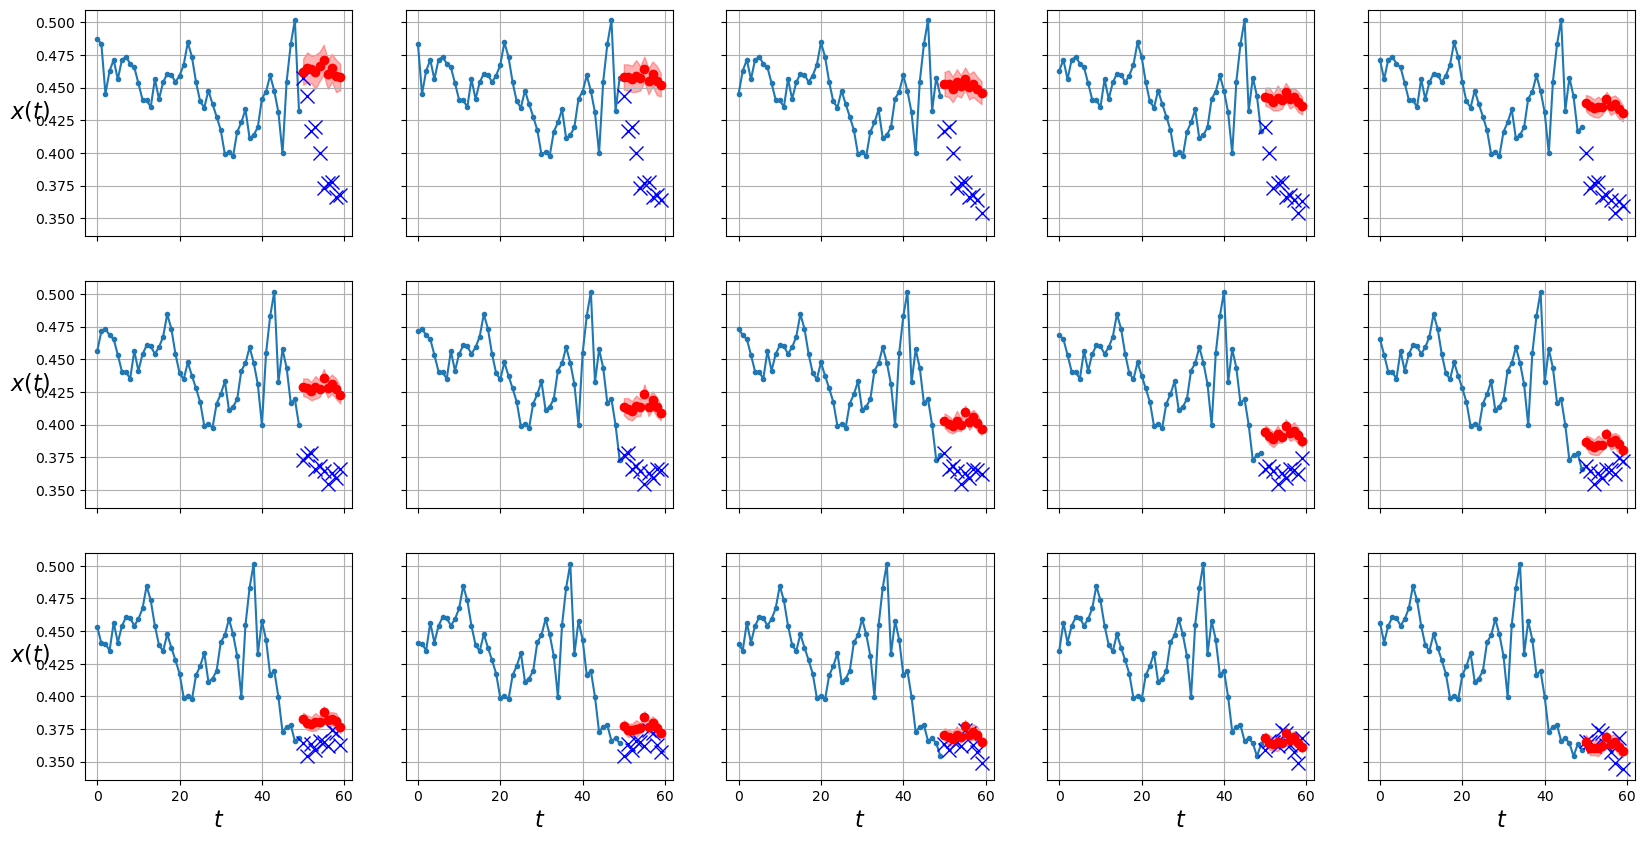

In [23]:
def plot_series_intervals(series, y=None, y_pred=None, y_pred_std=None, 
                          x_label="$t$", y_label="$x(t)$"):
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            plt.plot(series[ix], ".-")
            future_range = range(len(series[ix]), len(series[ix]) + 10)
            if y is not None:
                plt.plot(future_range, y[ix], "bx", markersize=10)
            if y_pred is not None:
                plt.plot(future_range, y_pred[ix], "ro")
            if y_pred_std is not None:
                # banda superior e inferior
                plt.fill_between(future_range,
                                 y_pred[ix] - y_pred_std[ix],
                                 y_pred[ix] + y_pred_std[ix],
                                 alpha=0.3, color='red',
                                 label='Intervalo de confianza')
            plt.grid(True)
            if x_label and row == r - 1:
                plt.xlabel(x_label, fontsize=16)
            if y_label and col == 0:
                plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.show()

plot_series_intervals(X_test_m, y_test_m, y_pred_mean, y_pred_std)

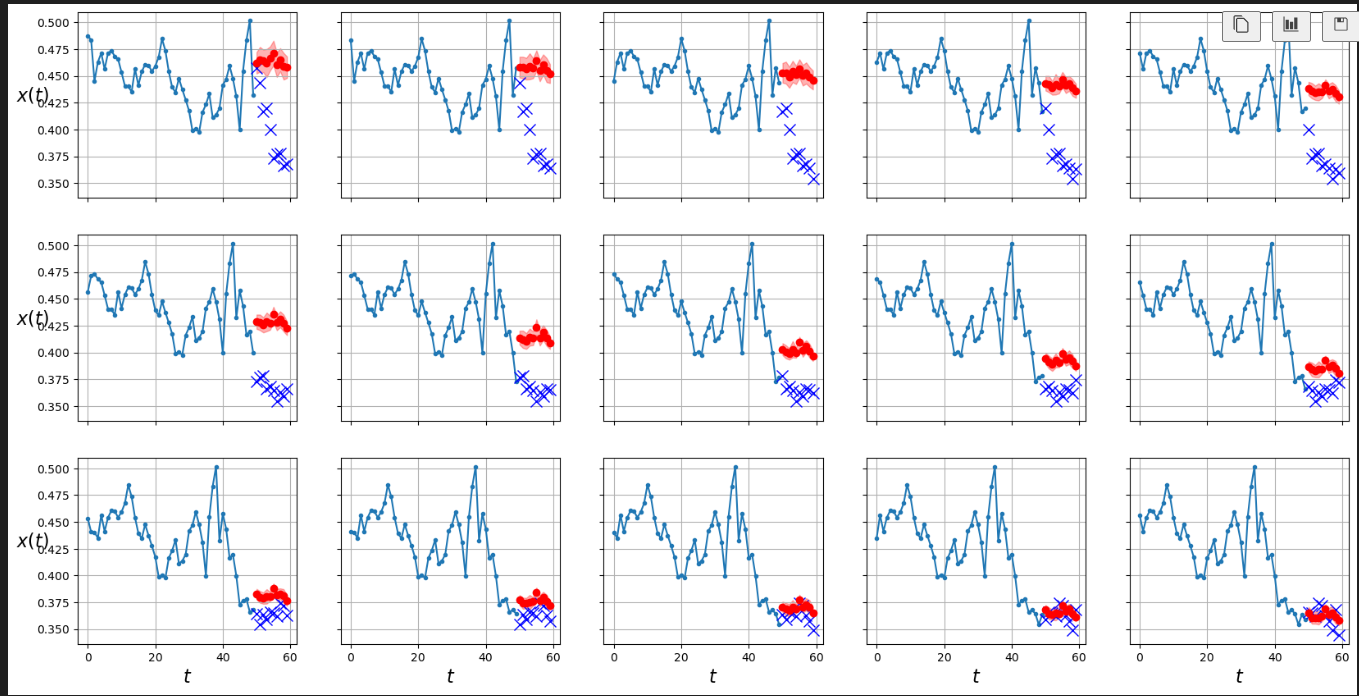

# CONCLUSIONES

La red neuronal recurrente profunda implementada con torch.nn.RNN de 2 capas y 20 neuronas ocultas obtuvo un RMSE de 0.1126 MXN para la predicción del par USD/MXN — levemente inferior al MLP. Si bien la RNN fue diseñada específicamente para datos secuenciales al procesar cada día como un paso temporal con memoria del estado anterior, en este caso no superó al MLP por tres razones principales. Primero, el dataset de 1608 registros es relativamente pequeño para explotar la ventaja de memoria de las RNN. Segundo, torch.nn.RNN sufre del problema de vanishing gradient en secuencias largas de 50 pasos, donde los gradientes se hacen tan pequeños que las capas profundas dejan de aprender efectivamente. Tercero, la tendencia del USD/MXN es suficientemente suave como para que el MLP la capture sin necesidad de memoria temporal explícita. La extensión a predicción de 10 valores futuros incrementó el RMSE a 0.1879 MW promedio y 0.2379 MW para el décimo día, confirmando que el error se acumula progresivamente con cada paso futuro adicional, lo cual es un comportamiento esperado en series temporales financieras donde la incertidumbre crece con el horizonte de predicción.